In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 
from ultralytics import YOLO
import torch
import torch.nn as nn
from loguru import logger
import os
import tensorrt as trt
import onnxruntime
import pytorch_quantization.nn as quant_nn
from pytorch_quantization.nn import TensorQuantizer  # 来自你QAT框架（如 MQBench 等）
import onnx
from onnxsim import simplify
print("ONNX Runtime版本:", onnxruntime.__version__)
print("可用设备:", onnxruntime.get_device())
print("支持Provider:", onnxruntime.get_available_providers())
print(f'trt version:{trt.__version__}')
print(f'torch cuda available:{torch.cuda.is_available()}')

ONNX Runtime版本: 1.22.0
可用设备: GPU
支持Provider: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
trt version:8.6.1
torch cuda available:True


In [2]:
def load_model(org_model_path, pt_model_path, device='cuda:0'):
    model = YOLO(org_model_path)
    model1 = torch.load(pt_model_path, map_location=device)["model"]
    model1.float()
    model1.eval()
    with torch.no_grad():
        model1.fuse()
    model.model = model1
    model.args = vars(model.args)
    model.model.args = model.args
    model.model.task = model.task
    return model
def print_model_size(pt_path):
    if os.path.exists(pt_path):
        size_bytes = os.path.getsize(pt_path)
        size_mb = size_bytes / (1024 * 1024)
        print(f"📦 模型文件大小: {size_bytes} 字节 ({size_mb:.2f} MB)")
    else:
        print("❌ 找不到该 .pt 文件，请检查路径是否正确")

In [3]:
data_yaml_file = './datasets/my-coco-pose.yaml' # 测试数据
device = 'cuda:0'

# 原始的yolov8s-pose

In [4]:
org_pt_path = './weights/yolov8s-pose.pt'
print_model_size(org_pt_path)

📦 模型文件大小: 23513657 字节 (22.42 MB)


In [27]:
dense_model = YOLO(org_pt_path, task='pose')
dense_model.info()

YOLOv8s-pose summary: 144 layers, 11,626,046 parameters, 0 gradients, 30.4 GFLOPs


(144, 11626046, 0, 30.406830400000004)

In [9]:
len(dense_model.model.state_dict())

397

**预测**

In [11]:
results = dense_model.predict("datasets/coco-pose/images/val2017/000000000139.jpg",device=device)  # predict on an image


image 1/1 /data/xl/Projects/EdgeLite/datasets/coco-pose/images/val2017/000000000139.jpg: 448x640 1 person, 4.4ms
Speed: 1.0ms preprocess, 4.4ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)


In [7]:
dense_model.device

device(type='cuda', index=0)

In [12]:
metrics = dense_model.val(data=data_yaml_file, device=device) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 11.5±6.9 MB/s, size: 156.5 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2346/2346 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 147/147 [00:14<00:00,  9.91


                   all       2346       6352      0.868      0.864       0.93      0.743      0.855      0.804      0.858      0.606
Speed: 0.1ms preprocess, 1.6ms inference, 0.0ms loss, 0.7ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val634/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val634/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.72s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.575
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.752
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.638
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.238
 Average Precision  (AP) @[ IoU=0.50:0.95 | are

In [24]:
dense_model.info()

YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs


(81, 11615724, 0, 30.190670400000002)

In [23]:
logger.info(f"Original model fp32 pt-->YOLO load model evaluate inference speed:{metrics.speed['inference']:.1f} ms")

2025-07-04 17:25:42.112 | INFO     | __main__:<module>:1 - Original model fp32 pt-->YOLO load model evaluate inference speed:1.0 ms


# FP16->TRT engine

* 在动态情况下只有minShapes=maxShapes=optShapes=1x3x640x640->即静态，相当于默认的官方导出engine(dynamic=False)
* 否则minShapes=images:batchx3x320x320, maxShapes=images:batchx3x640x640 可以跑
* engine_model.val()

**官方导出engine, 静态**

In [10]:
dense_model.export(format='engine', half=True, device=device)

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs

PyTorch: starting from 'weights/yolov8s-pose.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 56, 8400) (22.4 MB)

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.58...
ONNX: export success ✅ 1.2s, saved as 'weights/yolov8s-pose.onnx' (44.6 MB)

TensorRT: starting export with TensorRT 8.6.1...
[07/07/2025-19:32:44] [TRT] [I] [MemUsageChange] Init CUDA: CPU +1, GPU +0, now: CPU 2199, GPU 6023 (MiB)
[07/07/2025-19:32:52] [TRT] [I] [MemUsageChange] Init builder kernel library: CPU +1444, GPU +270, now: CPU 3720, GPU 6293 (MiB)
[07/07/2025-19:32:52] [TRT] [I] ----------------------------------------------------------------
[07/07/2025-19:32:52] [TRT] [I] Input filename:   weights/yolov8s-pose.onnx
[07/07/2025-19:32:52] [TRT] [I] ONNX IR version:  0.0.9
[07/07/2025-

'weights/yolov8s-pose.engine'

**官方导出engine, 动态**

In [6]:
# TensorRT FP16
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 
fp16_trt_engine = dense_model.export(format="engine", imgsz=640, dynamic=True, verbose=False, batch=8, workspace=2, half=True)

WARNING ⚠️ TensorRT requires GPU export, automatically assigning device=0
Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs

PyTorch: starting from 'weights/yolov8s-pose.pt' with input shape (8, 3, 640, 640) BCHW and output shape(s) (8, 56, 8400) (22.4 MB)

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.58...
ONNX: export success ✅ 4.0s, saved as 'weights/yolov8s-pose.onnx' (44.4 MB)

TensorRT: starting export with TensorRT 8.6.1...
[07/07/2025-20:37:09] [TRT] [I] [MemUsageChange] Init CUDA: CPU +2, GPU +0, now: CPU 893, GPU 2255 (MiB)
[07/07/2025-20:37:16] [TRT] [I] [MemUsageChange] Init builder kernel library: CPU +1445, GPU +266, now: CPU 2414, GPU 2521 (MiB)


KeyboardInterrupt: 

模型文件路径原始模型的pt文件路径将'pt'替换为'engine
即'./weights/yolov8s-pose.pt'->'./weights/yolov8s-pose.engine'

对其重命名:

In [7]:
import os
os.rename('./weights/yolov8s-pose.engine', './weights/yolov8s-pose-fp16.engine')

In [7]:
# fp16_trt_engine = YOLO('./weights/yolov8s-pose-fp16.engine', task='pose')
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
fp16_trt_engine = YOLO('./weights/yolov8s-pose-fp16.engine', task='pose')

**动态情况下一定要设置rect=False(特别是imgsz=640固定shape时)**

In [9]:
metrics = fp16_trt_engine.val(data=data_yaml_file, batch=16,imgsz=640, rect=False, verbose=False, device=device)
# metrics = model.val(data=data_yaml_file, batch=1,imgsz=640, rect=True, verbose=False, device=device) # 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
Loading weights/yolov8s-pose-fp16.engine for TensorRT inference...
[08/28/2025-18:22:50] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[08/28/2025-18:22:50] [TRT] [I] Loaded engine size: 26 MiB
[08/28/2025-18:22:50] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in engine deserialization: CPU +0, GPU +22, now: CPU 0, GPU 316 (MiB)
[08/28/2025-18:22:50] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +1, GPU +272, now: CPU 1, GPU 588 (MiB)
WARNING ⚠️ Metadata not found for 'model=./weights/yolov8s-pose-fp16.engine'
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2333.3±866.0 MB/s, size: 154.4 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache
                 Class     Images  Instances      Box(P          R      mAP50  m


                   all       2346       6352      0.868      0.855      0.925      0.733      0.854      0.807      0.856      0.605
Speed: 0.1ms preprocess, 0.4ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val26/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val26/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.50s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.560
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.735
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.622
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.198
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

In [62]:
metrics.speed

{'preprocess': 0.12346564153747637,
 'inference': 0.383697569057447,
 'loss': 0.000414514766477258,
 'postprocess': 0.46280918511675584}

In [47]:
fp16_infer_time = metrics.speed['inference']

In [48]:
logger.info(f"fp16 trt engine-->YOLO load model evaluate inference speed:{fp16_infer_time:.1f} ms")

2025-07-04 17:51:29.132 | INFO     | __main__:<module>:1 - fp16 trt engine-->YOLO load model evaluate inference speed:0.8 ms


In [36]:
!trtexec --loadEngine=weights/yolov8s-pose-fp16.engine --shapes=images:1x3x640x640

&&&& RUNNING TensorRT.trtexec [TensorRT v100700] [b23] # trtexec --loadEngine=weights/yolov8s-pose-fp16.engine --shapes=images:1x3x640x640
[07/05/2025-16:42:41] [I] TF32 is enabled by default. Add --noTF32 flag to further improve accuracy with some performance cost.
[07/05/2025-16:42:41] [I] === Model Options ===
[07/05/2025-16:42:41] [I] Format: *
[07/05/2025-16:42:41] [I] Model: 
[07/05/2025-16:42:41] [I] Output:
[07/05/2025-16:42:41] [I] 
[07/05/2025-16:42:41] [I] === System Options ===
[07/05/2025-16:42:41] [I] Device: 0
[07/05/2025-16:42:41] [I] DLACore: 
[07/05/2025-16:42:41] [I] Plugins:
[07/05/2025-16:42:41] [I] setPluginsToSerialize:
[07/05/2025-16:42:41] [I] dynamicPlugins:
[07/05/2025-16:42:41] [I] ignoreParsedPluginLibs: 0
[07/05/2025-16:42:41] [I] 
[07/05/2025-16:42:41] [I] === Inference Options ===
[07/05/2025-16:42:41] [I] Batch: Explicit
[07/05/2025-16:42:41] [I] Input inference shape : images=1x3x640x640
[07/05/2025-16:42:41] [I] Iterations: 10
[07/05/2025-16:42:41] [I

In [35]:
logger.info(f'fp16 trt engine, batch 16, gpu mean time/per img: 6.75ms')

2025-07-05 16:42:33.565 | INFO     | __main__:<module>:1 - fp16 trt engine, batch 16, gpu mean time/per img: 6.75ms


In [37]:
logger.info(f'fp16 trt engine, batch 1, gpu mean time/per img: 1.3ms')

2025-07-05 16:43:17.108 | INFO     | __main__:<module>:1 - fp16 trt engine, batch 1, gpu mean time/per img: 1.3ms


# PTQ

In [9]:
# 官方ptq,导出精度十分低！
dense_model.export(format='engine', imgsz=640, dynamic=True, verbose=False, batch=8, workspace=2, int8=True, data=data_yaml_file)

WARNING ⚠️ TensorRT requires GPU export, automatically assigning device=0
Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs

PyTorch: starting from 'weights/yolov8s-pose.pt' with input shape (8, 3, 640, 640) BCHW and output shape(s) (8, 56, 8400) (22.4 MB)

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.58...
ONNX: export success ✅ 4.1s, saved as 'weights/yolov8s-pose.onnx' (44.4 MB)

TensorRT: starting export with TensorRT 8.6.1...
TensorRT: collecting INT8 calibration images from 'data=./datasets/my-coco-pose.yaml'
Fast image access ✅ (ping: 0.0±0.0 ms, read: 3612.7±830.6 MB/s, size: 173.9 KB)


Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 1

[07/07/2025-21:43:56] [TRT] [I] The logger passed into createInferBuilder differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.


[07/07/2025-21:43:56] [TRT] [I] [MemUsageChange] Init CUDA: CPU +0, GPU +0, now: CPU 896, GPU 1117 (MiB)
[07/07/2025-21:44:03] [TRT] [I] [MemUsageChange] Init builder kernel library: CPU +1445, GPU +266, now: CPU 2417, GPU 1383 (MiB)
[07/07/2025-21:44:03] [TRT] [I] ----------------------------------------------------------------
[07/07/2025-21:44:03] [TRT] [I] Input filename:   weights/yolov8s-pose.onnx
[07/07/2025-21:44:03] [TRT] [I] ONNX IR version:  0.0.9
[07/07/2025-21:44:03] [TRT] [I] Opset version:    19
[07/07/2025-21:44:03] [TRT] [I] Producer name:    pytorch
[07/07/2025-21:44:03] [TRT] [I] Producer version: 2.4.1
[07/07/2025-21:44:03] [TRT] [I] Domain:           
[07/07/2025-21:44:03] [TRT] [I] Model version:    0
[07/07/2025-21:44:03] [TRT] [I] Doc string:       
[07/07/2025-21:44:03] [TRT] [I] ----------------------------------------------------------------
[07/07/2025-21:44:03] [TRT] [W] onnx2trt_utils.cpp:374: Your ONNX model has been generated with INT64 weights, while Te

'weights/yolov8s-pose.engine'

In [10]:
import os
os.rename('./weights/yolov8s-pose.engine', './weights/yolov8s-pose-ptq.engine')

In [ ]:
# 非官方手写ptq
!python main_quant.py --weight weights/yolov8s-pose.pt --onnx_path weights/yolov8s-pose.onnx --engine_path weights/yolov8s-pose-ptq.engine \
--cali_data_path datasets/coco-pose/images/train2017 --cali_size 5000 --output_dir output/yolov8s-pose-ptq --output_dir output/yolov8s-pose-ptq \
--quant ptq --batch_size 1 --eval

In [8]:
ptq_engine_path = 'weights/yolov8s-pose-ptq.engine'
# ptq_engine_path = 'weights/yolov8s-pose.engine'

In [9]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
ptq_trt_engine = YOLO(ptq_engine_path, task='pose')

In [10]:
metrics = ptq_trt_engine.val(data=data_yaml_file, rect=False, verbose=False, device=device)

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
Loading weights/yolov8s-pose-ptq.engine for TensorRT inference...
[09/02/2025-14:08:05] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[09/02/2025-14:08:05] [TRT] [I] Loaded engine size: 14 MiB
[09/02/2025-14:08:05] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in engine deserialization: CPU +0, GPU +11, now: CPU 0, GPU 314 (MiB)
[09/02/2025-14:08:05] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +1, GPU +292, now: CPU 1, GPU 606 (MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2819.4±451.0 MB/s, size: 185.7 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|█████████
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100


                   all       2346       6352      0.867      0.841      0.915      0.716      0.839      0.792      0.838      0.555
Speed: 0.1ms preprocess, 0.2ms inference, 0.0ms loss, 0.7ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val2/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val2/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.96s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.547
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.727
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.606
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.184
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=me

In [11]:
metrics = ptq_trt_engine.val(data=data_yaml_file, rect=False, verbose=False, device=device, batch=1)

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
Loading weights/yolov8s-pose-ptq.engine for TensorRT inference...
[09/02/2025-14:08:38] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[09/02/2025-14:08:38] [TRT] [I] Loaded engine size: 14 MiB
[09/02/2025-14:08:38] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in engine deserialization: CPU +0, GPU +11, now: CPU 0, GPU 314 (MiB)
[09/02/2025-14:08:38] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +1, GPU +292, now: CPU 1, GPU 606 (MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3405.1±705.9 MB/s, size: 124.3 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|█████████
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100


                   all       2346       6352      0.867      0.841      0.915      0.716      0.839      0.792      0.838      0.555
Speed: 0.1ms preprocess, 0.2ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val3/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val3/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.54s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.547
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.727
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.606
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.184
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=me

In [36]:
ptq_infer_time = metrics.speed['inference']

In [37]:
logger.info(f"ptq trt engine-->YOLO load model evaluate inference speed:{ptq_infer_time:.1f} ms")

2025-07-05 12:46:43.032 | INFO     | __main__:<module>:1 - ptq trt engine-->YOLO load model evaluate inference speed:0.7 ms


In [54]:
logger.info(f"ptq vs.fp16 trt engine, speed up {fp16_infer_time/ptq_infer_time:.1f}x")

2025-07-04 17:53:33.794 | INFO     | __main__:<module>:1 - ptq vs.fp16 trt engine, speed up 1.1x


# QAT

In [10]:
qat_pt_path = 'weights/yolov8s-pose-qat.pt'

In [11]:
qat_model = load_model("weights/yolov8s-pose.pt", 'weights/yolov8s-pose-qat.pt')

/tmp/ipykernel_166182/2157033058.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model1 = torch.load(pt_model_path, map_location=device)["model"]


In [97]:
data_yaml_file = './datasets/my-coco-pose.yaml'
# metrics = qat_model .val(data=data_yaml_file, batch=16, device='cuda:0') 
metrics = qat_model.val(data=data_yaml_file)

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 773.5±246.4 MB/s, size: 176.7 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2346/2346 [00:0
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 147/


                   all       2346       6352      0.871      0.854      0.928      0.701      0.846      0.808      0.857      0.592
Speed: 0.1ms preprocess, 1.5ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val604/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val604/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.62s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.546
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.753
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.627
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.238
 Average Precision  (AP) @[ IoU=0.50:0.95 | are

In [20]:
def enable_all_fake_quant(module):
    for m in module.modules():
        if isinstance(m, quant_nn.TensorQuantizer):
            m._fake_quant = True
    return module
def validate_onnx(file):
    model = onnx.load(file)
    model_simp, check = simplify(
        model,
        skip_fuse_bn=True,
        test_input_shapes={"images": [1, 3, 640, 640]},
    )
    onnx.save(model_simp, file)
    print(f"onnx validate finished , save to: {file}")
    print("========================\n")
qat_model = enable_all_fake_quant(qat_model)

path = qat_model.export(format='onnx', dynamic=True, imgsz=(640,1088), verbose=False, batch=16, workspace=2)

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CPU (Intel Xeon Platinum 8457C)

PyTorch: starting from 'yolov8s-pose.yaml' with input shape (16, 3, 640, 1088) BCHW and output shape(s) (16, 56, 14280) (0.0 MB)

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.58...
ONNX: export success ✅ 9.0s, saved as 'yolov8s-pose.onnx' (44.6 MB)

Export complete (17.1s)
Results saved to /data/xl/Projects/EdgeLite
Predict:         yolo predict task=pose model=yolov8s-pose.onnx imgsz=640,1088  
Validate:        yolo val task=pose model=yolov8s-pose.onnx imgsz=640,1088 data=./datasets/my-coco-pose.yaml  WARNING ⚠️ non-PyTorch val requires square images, 'imgsz=[640, 1088]' will not work. Use export 'imgsz=1088' if val is required.
Visualize:       https://netron.app


In [17]:
qat_model.device

device(type='cuda', index=0)

In [18]:
def export_yolov8_pose_onnx(
    model,
    onnx_path="yolov8s-pose-dynamic.onnx",
    img_height=640,
    img_width=1088,
    dynamic_batch=True,
    max_batch_size=16,
    opset_version=13,
    sim=False
):
    # 加载模型
    # model = YOLO(model_path, task='pose')
    model.eval()
    device = model.device

    # 动态或静态 batch
    if dynamic_batch:
        dummy_input = torch.randn(1, 3, img_height, img_width).to(device)  # 用于trace
        dynamic_axes = {
            "images": {0: "batch"},
            "output0": {0: "batch"}
        }
    else:
        dummy_input = torch.randn(1, 3, img_height, img_width).to(device)
        dynamic_axes = None

    # 设置导出参数
    torch.onnx.export(
        model.model,                         # 注意：ultralytics.YOLO的内部模型
        dummy_input,
        onnx_path,
        input_names=["images"],
        output_names=["output0"],
        export_params=True,
        opset_version=opset_version,
        do_constant_folding=True,
        dynamic_axes=dynamic_axes
    )
    print(f"ONNX 导出完成: {onnx_path}")
    if sim:
        onnx_model = onnx.load(onnx_path)
        onnx.checker.check_model(onnx_model) 
        try:
            onnx_model, check = onnxsim.simplify(onnx_model)
            assert check, 'assert check failed'
        except Exception as e:
            print(f'Simplifier failure: {e}')
        onnx.save(onnx_model, onnx_path)
        print(f'ONNX simplify export success, saved as {onnx_path}')

In [19]:
export_yolov8_pose_onnx(
    qat_model,
    onnx_path='weights/yolov8s-pose-qat-op13-h640w1088-dynamic.onnx',
    img_height=640,
    img_width=1088,
    dynamic_batch=True,
    max_batch_size=16,
    opset_version=13,
    sim=False
)

/usr/local/anaconda3/envs/yolov8-pose/lib/python3.10/site-packages/pytorch_quantization-2.2.1-py3.10-linux-x86_64.egg/pytorch_quantization/tensor_quant.py:324: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if amax.numel() == 1:
/usr/local/anaconda3/envs/yolov8-pose/lib/python3.10/site-packages/pytorch_quantization-2.2.1-py3.10-linux-x86_64.egg/pytorch_quantization/tensor_quant.py:327: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  axis = amax.shape.index(amax.numel())
/data/xl/Projects/EdgeLite/ultralytics/nn/modules/head.py:163: TracerWarning: Converti

ONNX 导出完成: weights/yolov8s-pose-qat-op13-h640w1088-dynamic.onnx


In [8]:
path

'yolov8s-pose.onnx'

In [10]:
qat_model.model_name

'weights/yolov8s-pose.pt'

In [101]:
validate_onnx('yolov8s-pose.onnx')

onnx validate finished , save to: yolov8s-pose.onnx



In [21]:
import os
os.rename(path, './weights/yolov8s-pose-qat.onnx')

In [103]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 

In [120]:
!trtexec --onnx=./weights/yolov8s-pose-qat.onnx --int8 --fp16 --saveEngine=./weights/yolov8s-pose-qat.engine --minShapes=images:1x3x640x640 --optShapes=images:16x3x640x640 --maxShapes=images:16x3x640x640

&&&& RUNNING TensorRT.trtexec [TensorRT v8601] # trtexec --onnx=./weights/yolov8s-pose-qat.onnx --int8 --fp16 --saveEngine=./weights/yolov8s-pose-qat.engine --minShapes=images:1x3x640x640 --optShapes=images:16x3x640x640 --maxShapes=images:16x3x640x640
[07/09/2025-13:01:29] [I] === Model Options ===
[07/09/2025-13:01:29] [I] Format: ONNX
[07/09/2025-13:01:29] [I] Model: ./weights/yolov8s-pose-qat.onnx
[07/09/2025-13:01:29] [I] Output:
[07/09/2025-13:01:29] [I] === Build Options ===
[07/09/2025-13:01:29] [I] Max batch: explicit batch
[07/09/2025-13:01:29] [I] Memory Pools: workspace: default, dlaSRAM: default, dlaLocalDRAM: default, dlaGlobalDRAM: default
[07/09/2025-13:01:29] [I] minTiming: 1
[07/09/2025-13:01:29] [I] avgTiming: 8
[07/09/2025-13:01:29] [I] Precision: FP32+FP16+INT8
[07/09/2025-13:01:29] [I] LayerPrecisions: 
[07/09/2025-13:01:29] [I] Layer Device Types: 
[07/09/2025-13:01:29] [I] Calibration: Dynamic
[07/09/2025-13:01:29] [I] Refit: Disabled
[07/09/2025-13:01:29] [I] Ve

In [121]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 
qat_engine_path = './weights/yolov8s-pose-qat.engine'
qat_model = YOLO(qat_engine_path, task='pose')

In [127]:
metrics = qat_model.val(data=data_yaml_file,batch=16, rect=False, device=device)

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
Loading weights/yolov8s-pose-qat.engine for TensorRT inference...
[07/09/2025-14:39:23] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[07/09/2025-14:39:23] [TRT] [I] Loaded engine size: 15 MiB
[07/09/2025-14:39:23] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in engine deserialization: CPU +0, GPU +12, now: CPU 1, GPU 403 (MiB)
[07/09/2025-14:39:23] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +1, GPU +184, now: CPU 2, GPU 587 (MiB)
WARNING ⚠️ Metadata not found for 'model=./weights/yolov8s-pose-qat.engine'
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 788.0±87.7 MB/s, size: 163.2 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2346/2346 [00:0
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 147/


                   all       2346       6352      0.871      0.847      0.922        0.7      0.851      0.801      0.854      0.591
Speed: 0.1ms preprocess, 0.2ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val624/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val624/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.57s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.540
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.737
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.613
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.199
 Average Precision  (AP) @[ IoU=0.50:0.95 | are

**--int8(fp32+int8)**

In [119]:
metrics.speed

{'preprocess': 0.1592556812990225,
 'inference': 0.3285312433909698,
 'loss': 0.00043988958491808007,
 'postprocess': 0.4968066672113297}

**--int8 --fp16 (fp32+fp16+int8)**

In [112]:
metrics.speed

{'preprocess': 0.14382310366283432,
 'inference': 0.20884833815098697,
 'loss': 0.0004549553452690036,
 'postprocess': 0.5027503953239891}

# prune

* 剪枝后的yolov8s-pose的pt->"./output/yolov8s-pose-prune-sp0.5-epoch60/step_19_finetune/weights/best.pt"
* 原始的yolov8s-pose的pt->'./weights/yolov8s-pose.pt'

In [17]:
# pt_path = "./output/yolov8s-pose-prune-sp0.5-epoch60/step_19_finetune/weights/best.pt"
pt_path = 'weights/yolov8s-pose-prune-sp0.7.pt'
print_model_size(pt_path)
# pt_path = "./output/yolov8s-pose-prune-sp0.3-epoch60/step_19_finetune/weights/best.pt"

📦 模型文件大小: 14755026 字节 (14.07 MB)


In [39]:
pt_path = "./output/yolov8s-pose-prune-sp0.3-epochs120/step_15_finetune/weights/best.pt"
print_model_size(pt_path)

📦 模型文件大小: 24346450 字节 (23.22 MB)


In [34]:
dense_model = YOLO(org_pt_path, task='pose')
dense_model.info()

YOLOv8s-pose summary: 144 layers, 11,626,046 parameters, 0 gradients, 30.4 GFLOPs


(144, 11626046, 0, 30.406830400000004)

In [14]:
len(dense_model.model.state_dict())

397

**为什么剪枝后的模型(33.4M)占用内存比dense模型还大呢(22.4M)？**

In [14]:
pruned_model = YOLO(pt_path, task='pose')
pruned_model.info()
# pruned_model = load_model(org_pt_path, pt_path)

YOLOv8s-pose summary: 161 layers, 4,701,718 parameters, 0 gradients, 13.2 GFLOPs


(161, 4701718, 0, 13.213389600000001)

In [18]:
pruned_model = YOLO(pt_path, task='pose')
pruned_model.info()
# pruned_model = load_model(org_pt_path, pt_path)

YOLOv8s-pose summary: 161 layers, 3,612,969 parameters, 0 gradients, 10.7 GFLOPs


(161, 3612969, 0, 10.6666712)

In [16]:
dense_model.model.state_dict()

OrderedDict([('model.0.conv.weight',
              tensor([[[[ 9.9548e-02,  3.0167e-02, -1.3452e-01],
                        [ 2.8107e-02,  3.6102e-02,  2.0828e-02],
                        [-1.7322e-01, -2.4338e-02,  1.1847e-01]],
              
                       [[ 1.2006e-01,  4.3884e-02, -1.6614e-01],
                        [ 1.3208e-03,  2.9129e-02,  6.4468e-03],
                        [-1.6260e-01, -1.7975e-02,  1.4673e-01]],
              
                       [[ 3.9337e-02,  2.2278e-02, -8.3679e-02],
                        [ 1.9821e-02,  1.5282e-02, -1.0155e-02],
                        [-5.7129e-02,  5.7945e-03,  4.2664e-02]]],
              
              
                      [[[ 6.2218e-03, -6.9092e-02, -3.3112e-02],
                        [-5.0873e-02, -1.8262e-01, -1.1749e-01],
                        [-1.7914e-02, -1.0370e-01, -6.2805e-02]],
              
                       [[ 1.8341e-02,  7.0740e-02,  1.3794e-02],
                        [ 4.7058e-02, 

In [15]:
pruned_model.model.state_dict()

OrderedDict([('model.0.conv.weight',
              tensor([[[[ 9.2090e-01,  4.6484e-01,  9.1113e-01],
                        [ 5.7666e-01, -2.3792e-01,  6.1963e-01],
                        [-5.9424e-01, -1.9834e+00, -5.5029e-01]],
              
                       [[ 6.9434e-01,  3.5327e-01,  6.6309e-01],
                        [ 5.0049e-01, -2.8101e-01,  4.9243e-01],
                        [-4.3311e-01, -1.7344e+00, -4.0186e-01]],
              
                       [[ 3.8550e-01,  8.7891e-02,  3.3496e-01],
                        [ 3.4106e-01, -2.2949e-01,  3.1299e-01],
                        [-1.3000e-01, -1.0732e+00, -1.5723e-01]]],
              
              
                      [[[-1.1359e-01,  1.1908e-01,  2.9883e-01],
                        [ 1.0815e-01,  4.4678e-02, -1.3818e-01],
                        [ 1.6272e-01, -8.9172e-02, -7.1289e-01]],
              
                       [[-3.6957e-02,  5.9128e-03,  1.5405e-01],
                        [ 5.7800e-02, 

In [31]:
len(pruned_model.model.model)

23

In [10]:
# engine1 = YOLO("weights/yolov8s-pose-prune-sp0.5-op13-h640w1088-dynamic.engine", task='pose')
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
engine = YOLO("weights/yolov8s-pose-prune-sp0.7-distill-h640w640-fp16.engine", task='pose')
# metrics1 = engine.val(data=data_yaml_file, rect=False, batch=16, imgsz=640, device=device) 
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 
metrics2 = engine.val(data=data_yaml_file, rect=False, batch=16, imgsz=640, device=device) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
Loading weights/yolov8s-pose-prune-sp0.7-distill-h640w640-fp16.engine for TensorRT inference...
[09/04/2025-12:20:34] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[09/04/2025-12:20:34] [TRT] [I] Loaded engine size: 26 MiB
[09/04/2025-12:20:34] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in engine deserialization: CPU +0, GPU +22, now: CPU 1, GPU 987 (MiB)
[09/04/2025-12:20:34] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +272, now: CPU 1, GPU 1259 (MiB)
WARNING ⚠️ Metadata not found for 'model=weights/yolov8s-pose-prune-sp0.7-distill-h640w640-fp16.engine'
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3808.9±399.3 MB/s, size: 209.7 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images,
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pos


                   all       2346       6352      0.879      0.836       0.92      0.718      0.849      0.783      0.831      0.549
Speed: 0.1ms preprocess, 0.4ms inference, 0.0ms loss, 0.7ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val71/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val71/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.47s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.543
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.722
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.605
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.192
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**sp0.7 640**

In [37]:
metrics = pruned_model.val(data=data_yaml_file, batch=16, device=device) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4406.4±1013.5 MB/s, size: 150.3 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 co
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      


                   all       2346       6352      0.869      0.814      0.905      0.689      0.842      0.738      0.794      0.495
Speed: 0.1ms preprocess, 0.5ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val11/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val11/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.54s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.525
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.717
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.585
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.216
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**sp0.7 1088**

In [20]:
metrics = pruned_model.val(data=data_yaml_file, batch=16, imgsz=1088, device=device) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 90 layers, 3,607,378 parameters, 0 gradients, 10.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4018.0±1130.7 MB/s, size: 127.4 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R


                   all       2346       6352      0.801      0.793      0.861      0.605      0.764      0.733      0.759      0.461
Speed: 0.3ms preprocess, 1.6ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val55/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val55/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.63s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.505
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.742
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.552
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.302
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**sp0.6 640**

In [45]:
metrics = pruned_model.val(data=data_yaml_file, batch=16, device=device) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 90 layers, 4,695,277 parameters, 0 gradients, 13.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4462.1±1083.0 MB/s, size: 175.1 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 co
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      


                   all       2346       6352      0.871      0.822      0.912      0.703      0.836       0.77      0.818      0.526
Speed: 0.1ms preprocess, 0.8ms inference, 0.0ms loss, 0.4ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val14/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val14/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.48s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.537
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.726
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.594
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.219
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**sp0.6 1088**

In [15]:
metrics = pruned_model.val(data=data_yaml_file, batch=16, imgsz=1088, device=device) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 90 layers, 4,695,277 parameters, 0 gradients, 13.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4574.6±1093.6 MB/s, size: 198.9 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R


                   all       2346       6352      0.806      0.812      0.875      0.626      0.761      0.761      0.776      0.483
Speed: 0.2ms preprocess, 1.9ms inference, 0.0ms loss, 0.4ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val53/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val53/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.97s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.520
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.750
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.565
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.304
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**sp0.5 640**

In [48]:
metrics = pruned_model.val(data=data_yaml_file, batch=16, device=device)

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 90 layers, 5,999,648 parameters, 0 gradients, 15.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1922.4±289.3 MB/s, size: 152.4 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 co
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      


                   all       2346       6352      0.863      0.844      0.919      0.715      0.832      0.784      0.826      0.547
Speed: 0.1ms preprocess, 0.7ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val15/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val15/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.46s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.548
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.733
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.611
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.230
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**sp0.5 1088**

In [12]:
metrics = pruned_model.val(data=data_yaml_file, batch=16, imgsz=1088, device=device)

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 90 layers, 5,999,648 parameters, 0 gradients, 15.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4207.5±571.5 MB/s, size: 182.8 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R


                   all       2346       6352      0.828      0.813      0.884      0.639       0.78      0.767      0.787      0.504
Speed: 0.3ms preprocess, 3.5ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val52/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val52/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.53s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.525
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.750
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.577
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.306
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

In [43]:
metrics = pruned_model.val(data=data_yaml_file, batch=16, device=device) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3106.8±502.7 MB/s, size: 118.8 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache
                 Class     Images  Instances      Box(P          R      mAP50  m


                   all       2346       6352      0.867      0.849      0.925      0.725      0.842      0.788      0.839      0.564
Speed: 0.1ms preprocess, 0.8ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val10/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val10/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.45s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.554
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.738
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.615
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.228
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

In [14]:
metrics

ultralytics.utils.metrics.PoseMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x771042073430>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(P)', 'F1-Confidence(P)', 'Precision-Confidence(P)', 'Recall-Confidence(P)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034, 

In [34]:
metrics = pruned_model.val(data=data_yaml_file, batch=16, device=device) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3171.7±533.7 MB/s, size: 114.9 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2346/234
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|█████████


                   all       2346       6352      0.869      0.814      0.905      0.689      0.842      0.738      0.794      0.495
Speed: 0.1ms preprocess, 0.5ms inference, 0.0ms loss, 0.4ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val633/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val633/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.51s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.525
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.717
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.585
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.216
 Average Precision  (AP) @[ IoU=0.50:0.95 | are

In [23]:
logger.info(f"pruning sp0.5 pt-->YOLO load model evaluate inference speed:{metrics.speed['inference']:.1f} ms")

2025-07-07 22:03:47.308 | INFO     | __main__:<module>:1 - pruning sp0.5 pt-->YOLO load model evaluate inference speed:0.5 ms


In [24]:
logger.info(f"pruning sp0.3 pt-->YOLO load model evaluate inference speed:{metrics.speed['inference']:.1f} ms")

2025-07-07 22:03:47.313 | INFO     | __main__:<module>:1 - pruning sp0.3 pt-->YOLO load model evaluate inference speed:0.5 ms


**注意,我们发现，多次运行会得到不一样的结果，取值分别有1.3、0.9、0.8、0.6、0.5、0.4ms**
* 可以YOLO加载model以及load_model加载model多次切换运行，就可以得到0.4ms

**Pruned fp16 trt engine**

In [86]:
pruned_fp16_engine_path = pruned_model.export(format='engine', imgsz=640, dynamic=True, verbose=False, batch=16, workspace=2, half=True)

WARNING ⚠️ TensorRT requires GPU export, automatically assigning device=0
Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)

PyTorch: starting from 'output/yolov8s-pose-prune-sp0.3-epochs120/step_6_finetune/weights/best.pt' with input shape (16, 3, 640, 640) BCHW and output shape(s) (16, 56, 8400) (33.4 MB)

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.58...
ONNX: export success ✅ 3.9s, saved as 'output/yolov8s-pose-prune-sp0.3-epochs120/step_6_finetune/weights/best.onnx' (33.2 MB)

TensorRT: starting export with TensorRT 8.6.1...
[07/09/2025-11:53:42] [TRT] [I] [MemUsageChange] Init CUDA: CPU +0, GPU +0, now: CPU 1822, GPU 18753 (MiB)
[07/09/2025-11:53:48] [TRT] [I] [MemUsageChange] Init builder kernel library: CPU +1443, GPU +252, now: CPU 3265, GPU 19005 (MiB)
[07/09/2025-11:53:48] [TRT] [I] ----------------------------------------------------------------
[07/09/2025-11:53:48] [TRT] [I] Input filename:   outpu

In [44]:
pruned_model.export(format='onnx', dynamic=True, imgsz=640, simplify=True, device=device)

Ultralytics 8.3.155 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)

PyTorch: starting from 'output/yolov8s-pose-prune-sp0.5-epoch60/step_18_finetune/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 56, 8400) (14.5 MB)

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.58...
ONNX: export success ✅ 3.4s, saved as 'output/yolov8s-pose-prune-sp0.5-epoch60/step_18_finetune/weights/best.onnx' (13.5 MB)

Export complete (3.4s)
Results saved to /data/xl/Projects/EdgeLite/output/yolov8s-pose-prune-sp0.5-epoch60/step_18_finetune/weights
Predict:         yolo predict task=pose model=output/yolov8s-pose-prune-sp0.5-epoch60/step_18_finetune/weights/best.onnx imgsz=640  
Validate:        yolo val task=pose model=output/yolov8s-pose-prune-sp0.5-epoch60/step_18_finetune/weights/best.onnx imgsz=640 data=./datasets/my-coco-pose.yaml  
Visualize:       https://netron.app


'output/yolov8s-pose-prune-sp0.5-epoch60/step_18_finetune/weights/best.onnx'

In [46]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 
!trtexec --onnx='output/yolov8s-pose-prune-sp0.5-epoch60/step_18_finetune/weights/best.onnx' --fp16 --saveEngine='output/yolov8s-pose-prune-sp0.5-epoch60/step_18_finetune/weights/best.engine' --minShapes=images:1x3x640x640 --maxShapes=images:16x3x640x640 --optShapes=images:12x3x640x640

&&&& RUNNING TensorRT.trtexec [TensorRT v100700] [b23] # trtexec --onnx=output/yolov8s-pose-prune-sp0.5-epoch60/step_18_finetune/weights/best.onnx --fp16 --saveEngine=output/yolov8s-pose-prune-sp0.5-epoch60/step_18_finetune/weights/best.engine --minShapes=images:1x3x640x640 --maxShapes=images:16x3x640x640 --optShapes=images:12x3x640x640
[07/05/2025-12:58:32] [I] === Model Options ===
[07/05/2025-12:58:32] [I] Format: ONNX
[07/05/2025-12:58:32] [I] Model: output/yolov8s-pose-prune-sp0.5-epoch60/step_18_finetune/weights/best.onnx
[07/05/2025-12:58:32] [I] Output:
[07/05/2025-12:58:32] [I] === Build Options ===
[07/05/2025-12:58:32] [I] Memory Pools: workspace: default, dlaSRAM: default, dlaLocalDRAM: default, dlaGlobalDRAM: default, tacticSharedMem: default
[07/05/2025-12:58:32] [I] avgTiming: 8
[07/05/2025-12:58:32] [I] Precision: FP32+FP16
[07/05/2025-12:58:32] [I] LayerPrecisions: 
[07/05/2025-12:58:32] [I] Layer Device Types: 
[07/05/2025-12:58:32] [I] Calibration: 
[07/05/2025-12:58

In [49]:
pruned_fp16_engine_path

'output/yolov8s-pose-prune-sp0.5-epoch60/step_18_finetune/weights/best.engine'

In [87]:
# pruned_fp16_engine_path = 'output/yolov8s-pose-prune-sp0.5-epoch60/step_18_finetune/weights/best.engine'
pruned_fp16_engine_path = 'output/yolov8s-pose-prune-sp0.3-epochs120/step_6_finetune/weights/best.engine'

In [27]:
os.rename(pruned_fp16_engine_path, './weights/yolov8s-pose-pruned-sp0.5-fp16.engine')

In [88]:
# pruned_fp16_trt_engine = YOLO('./weights/yolov8s-pose-pruned-sp0.3-fp16.engine', task='pose')
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 
pruned_fp16_trt_engine = YOLO(pruned_fp16_engine_path, task='pose')

In [90]:
metrics = pruned_fp16_trt_engine.val(data=data_yaml_file,batch=1, rect=False, verbose=False, device=device)

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
Loading output/yolov8s-pose-prune-sp0.3-epochs120/step_6_finetune/weights/best.engine for TensorRT inference...
[07/09/2025-12:00:28] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[07/09/2025-12:00:28] [TRT] [I] Loaded engine size: 21 MiB
[07/09/2025-12:00:28] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in engine deserialization: CPU +0, GPU +18, now: CPU 0, GPU 1179 (MiB)
[07/09/2025-12:00:28] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +1, GPU +1144, now: CPU 1, GPU 2323 (MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1196.1±843.1 MB/s, size: 102.1 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2346/2346 [00:0
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 147/


                   all       2346       6352      0.867      0.846      0.922      0.726      0.845      0.804      0.847      0.577
Speed: 0.1ms preprocess, 0.4ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val591/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val591/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.56s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.551
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.726
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.613
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.194
 Average Precision  (AP) @[ IoU=0.50:0.95 | are

In [91]:
metrics.speed

{'preprocess': 0.12907418602035847,
 'inference': 0.42045535266642337,
 'loss': 0.000513308947129399,
 'postprocess': 0.536118865734441}

In [68]:
metrics.speed

{'preprocess': 0.1036744346033912,
 'inference': 0.4730086527702868,
 'loss': 0.00043406574220697494,
 'postprocess': 0.44061620816991737}

In [31]:
!trtexec --loadEngine=weights/yolov8s-pose-pruned-sp0.5-fp16.engine --shapes=images:16x3x640x640

&&&& RUNNING TensorRT.trtexec [TensorRT v100700] [b23] # trtexec --loadEngine=weights/yolov8s-pose-pruned-sp0.5-fp16.engine --shapes=images:16x3x640x640
[07/05/2025-16:30:44] [I] TF32 is enabled by default. Add --noTF32 flag to further improve accuracy with some performance cost.
[07/05/2025-16:30:44] [I] === Model Options ===
[07/05/2025-16:30:44] [I] Format: *
[07/05/2025-16:30:44] [I] Model: 
[07/05/2025-16:30:44] [I] Output:
[07/05/2025-16:30:44] [I] 
[07/05/2025-16:30:44] [I] === System Options ===
[07/05/2025-16:30:44] [I] Device: 0
[07/05/2025-16:30:44] [I] DLACore: 
[07/05/2025-16:30:44] [I] Plugins:
[07/05/2025-16:30:44] [I] setPluginsToSerialize:
[07/05/2025-16:30:44] [I] dynamicPlugins:
[07/05/2025-16:30:44] [I] ignoreParsedPluginLibs: 0
[07/05/2025-16:30:44] [I] 
[07/05/2025-16:30:44] [I] === Inference Options ===
[07/05/2025-16:30:44] [I] Batch: Explicit
[07/05/2025-16:30:44] [I] Input inference shape : images=16x3x640x640
[07/05/2025-16:30:44] [I] Iterations: 10
[07/05/20

In [39]:
!trtexec --loadEngine=weights/yolov8s-pose-pruned-sp0.5-fp16.engine --shapes=images:1x3x640x640

&&&& RUNNING TensorRT.trtexec [TensorRT v100700] [b23] # trtexec --loadEngine=weights/yolov8s-pose-pruned-sp0.5-fp16.engine --shapes=images:1x3x640x640
[07/05/2025-16:45:43] [I] TF32 is enabled by default. Add --noTF32 flag to further improve accuracy with some performance cost.
[07/05/2025-16:45:43] [I] === Model Options ===
[07/05/2025-16:45:43] [I] Format: *
[07/05/2025-16:45:43] [I] Model: 
[07/05/2025-16:45:43] [I] Output:
[07/05/2025-16:45:43] [I] 
[07/05/2025-16:45:43] [I] === System Options ===
[07/05/2025-16:45:43] [I] Device: 0
[07/05/2025-16:45:43] [I] DLACore: 
[07/05/2025-16:45:43] [I] Plugins:
[07/05/2025-16:45:43] [I] setPluginsToSerialize:
[07/05/2025-16:45:43] [I] dynamicPlugins:
[07/05/2025-16:45:43] [I] ignoreParsedPluginLibs: 0
[07/05/2025-16:45:43] [I] 
[07/05/2025-16:45:43] [I] === Inference Options ===
[07/05/2025-16:45:43] [I] Batch: Explicit
[07/05/2025-16:45:43] [I] Input inference shape : images=1x3x640x640
[07/05/2025-16:45:43] [I] Iterations: 10
[07/05/2025

In [38]:
logger.info(f'pruning sp0.5 fp16 trt engine, batch 16, gpu mean time/per img: 2.9ms')

2025-07-05 16:45:31.164 | INFO     | __main__:<module>:1 - pruning sp0.5 fp16 trt engine, batch 16, gpu mean time/per img: 2.9ms


In [40]:
logger.info(f'pruning sp0.5 fp16 trt engine, batch 1, gpu mean time/per img: 0.9ms')

2025-07-05 16:46:06.467 | INFO     | __main__:<module>:1 - pruning sp0.5 fp16 trt engine, batch 1, gpu mean time/per img: 0.9ms


In [39]:
logger.info(f"pruning sp0.3 fp16 engine-->YOLO load model evaluate inference speed:{metrics.speed['inference']:.1f} ms")

2025-07-04 23:35:11.764 | INFO     | __main__:<module>:1 - pruning sp0.3 fp16 engine-->YOLO load model evaluate inference speed:0.7 ms


In [40]:
logger.info(f"pruning sp0.5 fp16 engine-->YOLO load model evaluate inference speed:{metrics.speed['inference']:.1f} ms")

2025-07-04 23:35:14.649 | INFO     | __main__:<module>:1 - pruning sp0.5 fp16 engine-->YOLO load model evaluate inference speed:0.7 ms


**非动态情况下导出的engine都是0.7ms**

In [7]:
logger.info(f"pruning sp0.5 fp16 engine from function load_model-->YOLO load model evaluate inference speed:{metrics.speed['inference']:.1f} ms")

2025-07-04 21:46:30.015 | INFO     | __main__:<module>:1 - pruning sp0.5 fp16 engine from function load_model-->YOLO load model evaluate inference speed:0.2 ms


注意我们推断0.2ms是动态shape,此情况下类似与--minShapes=images:16x3x320x320 --maxShapes=images:16x3x1024x1024 --optShapes=images:16x3x640x640
* 推理速度极快
* 但精度却掉点十分严重

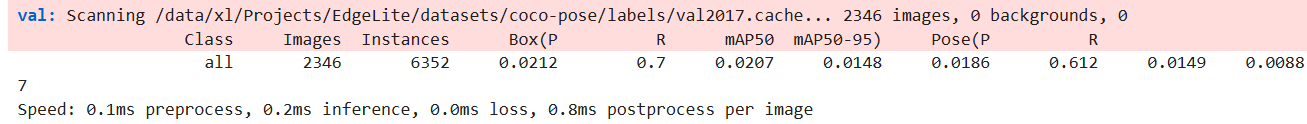

目前我们尝试的参数中，只用--minShapes=images:1x3x640x640 --maxShapes=images:1x3x640x640 --optShapes=images:1x3x640x640
* 能准确跑出精确度
* 但推理速度为1ms、0.9ms、0.8ms、0.7ms等值
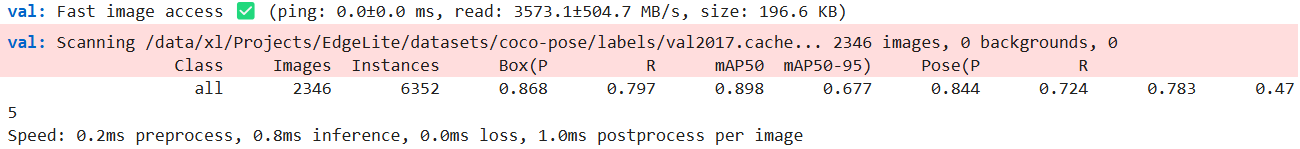

**利用YOLO导出的静态engine(dynamic不设置)与onnx导出并在trtextec中设置1x3x640x640是等效的-->静态**
* 都可以正确预测精度
* 但是推理速度较慢-->0.8-1ms

**要想动态推理，需要单独写一个engine的推理代码,在数据处理这一阶段满足动态处理要求**

# 蒸馏

In [66]:
# distill_path = "./weights/yolov8s-pose-prune-sp0.5-distill.pt"
# distill_path = "./weights/yolov8s-pose-prune-sp0.5-distill-h640w640.pt"
# distill_path = "./output/yolov8s-pose-prune-sp0.5-h640w640-distill100/train8/weights/best.pt"
# distill_path = "./output/yolov8s-pose-prune-sp0.6-distill100/train32/weights/best.pt"
# distill_path = "./output/yolov8s-pose-prune-sp0.7-distill100/train22/weights/best.pt"
# distill_path = "./output/yolov8s-pose-qat-distill100/train2/weights/best.pt"
distill_path = "./weights/yolov8s-pose-qat.pt"
# distill_path = "./weights/yolov8s-pose-prune-sp0.6-distill-h640w1088.pt"
# distill_path = "./weights/yolov8s-pose-prune-sp0.7-distill-h640w1088.pt"
# distill_path = "./weights/yolov8s-pose-prune-sp0.7-distill.pt"

In [132]:
model_s = YOLO('./weights/yolov8s-pose-qat.engine', task='pose')

In [127]:
x = torch.empty(10,3,640,640)

In [105]:
model_s.model.model

Sequential(
  (0): Conv(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (1): Conv(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (2): C2f(
    (cv1): Conv(
      (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (cv2): Conv(
      (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (m): ModuleList(
      (0): Bottleneck(
        (cv1): Conv(
        

In [106]:
print_model_size('./weights/yolov8s-pose-qat-distill100.pt')

📦 模型文件大小: 23532945 字节 (22.44 MB)


In [133]:
metrics = model_s.val(data=data_yaml_file, batch=16, rect=False, device=device, imgsz=640) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
Loading weights/yolov8s-pose-qat.engine for TensorRT inference...
[09/12/2025-13:36:30] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[09/12/2025-13:36:31] [TRT] [I] Loaded engine size: 15 MiB
[09/12/2025-13:36:31] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in engine deserialization: CPU +0, GPU +11, now: CPU 1, GPU 391 (MiB)
[09/12/2025-13:36:31] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +1, GPU +185, now: CPU 2, GPU 576 (MiB)
WARNING ⚠️ Metadata not found for 'model=./weights/yolov8s-pose-qat.engine'
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2849.8±948.9 MB/s, size: 120.2 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|███
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95


                   all       2346       6352      0.871      0.847      0.922        0.7      0.851      0.801      0.854      0.591
Speed: 0.3ms preprocess, 0.3ms inference, 0.0ms loss, 3.7ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val107/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val107/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.47s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.540
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.737
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.613
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.199
 Average Precision  (AP) @[ IoU=0.50:0.95 | are

In [99]:
model_s.info()

YOLOv8s-pose summary: 144 layers, 11,626,046 parameters, 0 gradients, 30.4 GFLOPs


(144, 11626046, 0, 30.406830400000004)

In [131]:
metrics = model_s.val(data=data_yaml_file, batch=16, rect=False, device=device, imgsz=640) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
Loading weights/yolov8s-pose-qat-distill100.engine for TensorRT inference...
[09/12/2025-13:35:13] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[09/12/2025-13:35:13] [TRT] [I] Loaded engine size: 14 MiB
[09/12/2025-13:35:13] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in engine deserialization: CPU +0, GPU +11, now: CPU 0, GPU 201 (MiB)
[09/12/2025-13:35:13] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +1, GPU +179, now: CPU 1, GPU 380 (MiB)
WARNING ⚠️ Metadata not found for 'model=./weights/yolov8s-pose-qat-distill100.engine'
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2874.6±1211.8 MB/s, size: 122.8 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|███
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95


                   all       2346       6352      0.888      0.837      0.924      0.708      0.858      0.806      0.857      0.581
Speed: 0.4ms preprocess, 0.4ms inference, 0.0ms loss, 3.9ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val106/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val106/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.46s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.540
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.730
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.616
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.190
 Average Precision  (AP) @[ IoU=0.50:0.95 | are

In [100]:
metrics = model_s.val(data=data_yaml_file, batch=16, device=device, imgsz=640) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2801.9±1180.8 MB/s, size: 126.7 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|███
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95


                   all       2346       6352      0.883      0.854      0.932      0.746      0.852      0.814      0.863      0.605
Speed: 0.3ms preprocess, 1.8ms inference, 0.0ms loss, 4.6ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val103/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val103/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.43s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.572
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.745
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.633
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.233
 Average Precision  (AP) @[ IoU=0.50:0.95 | are

In [107]:
metrics = model_s.val(data=data_yaml_file, batch=16, device=device, imgsz=1088) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3376.3±402.1 MB/s, size: 159.7 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|███
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95


                   all       2346       6352      0.849      0.836      0.907      0.683      0.817      0.797      0.836      0.577
Speed: 0.5ms preprocess, 5.6ms inference, 0.0ms loss, 4.0ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val104/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val104/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.93s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.545
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.750
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.598
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.289
 Average Precision  (AP) @[ IoU=0.50:0.95 | are

In [86]:
model = YOLO('weights/yolov8s-pose-prune-sp0.7.pt', task='pose')

In [90]:
metrics = model.val(data=data_yaml_file, batch=16, device=device, imgsz=640)

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 90 layers, 3,607,378 parameters, 0 gradients, 10.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3549.7±218.5 MB/s, size: 166.1 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|███
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95


                   all       2346       6352      0.869      0.814      0.905      0.689      0.842      0.738      0.794      0.495
Speed: 0.2ms preprocess, 0.6ms inference, 0.0ms loss, 2.0ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val102/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val102/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.54s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.525
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.717
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.585
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.216
 Average Precision  (AP) @[ IoU=0.50:0.95 | are

In [93]:
from compression.prune.utils import save_model_v2, final_eval_v2, strip_optimizer_v2, train_v2, replace_c2f_with_c2f_v2, save_pruning_performance_graph, plot_pruning_performance
from ultralytics.utils.torch_utils import initialize_weights
def load_model(weight, device="cuda:0"):
    model = YOLO(weight)
    # ✅ 添加防止 fallback 的关键字段
    model.pt_path = weight
    if not hasattr(model, 'args'):
        model.args = {"model": weight}  # 防止 AMP fallback
    model.__setattr__("train_v2", train_v2.__get__(model))
    model.model.train()
    replace_c2f_with_c2f_v2(model.model)
    initialize_weights(model.model)  # set BN.eps, momentum, ReLU.inplace
    for name, param in model.model.named_parameters():
        param.requires_grad = True
    model.to(device)
    return model

In [94]:
model = load_model('weights/yolov8s-pose-prune-sp0.7.pt')

In [95]:
model.info()

YOLO11n summary: 198 layers, 2,624,080 parameters, 2,624,080 gradients, 6.6 GFLOPs


(198, 2624080, 2624080, 6.614336)

In [80]:
print_model_size('weights/yolov8s-pose-prune-sp0.7.pt')

📦 模型文件大小: 14755026 字节 (14.07 MB)


In [72]:
model = torch.load("./output/yolov8s-pose-qat-distill100/train2/weights/best.pt", map_location="cpu")["model"]

/tmp/ipykernel_3900549/205043122.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("./output/yolov8s-pose-qat-distill100/train2/weights/best.pt", map_lo

In [61]:
metrics = distill_model.val(data=data_yaml_file, batch=16, device=device, imgsz=640) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3440.2±268.8 MB/s, size: 177.2 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|███
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95


                   all       2346       6352      0.871      0.856      0.929      0.743       0.86      0.801       0.86      0.601
Speed: 0.3ms preprocess, 1.6ms inference, 0.0ms loss, 2.9ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val99/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val99/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.52s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.575
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.751
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.635
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.243
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

In [50]:
metrics = distill_model.val(data=data_yaml_file, batch=16, device=device, imgsz=640) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3203.1±614.4 MB/s, size: 159.0 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|███
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95


                   all       2346       6352      0.871      0.856      0.929      0.743       0.86      0.801       0.86      0.601
Speed: 0.2ms preprocess, 1.4ms inference, 0.0ms loss, 2.0ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val95/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val95/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.46s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.575
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.751
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.635
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.243
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

In [67]:
distill_model = YOLO(distill_path, task='pose')
# distill_model = load_model(org_pt_path, distill_path)

In [65]:
distill_model

YOLO(
  (model): PoseModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=

In [49]:
print_model_size(distill_path)

📦 模型文件大小: 46869420 字节 (44.70 MB)


In [44]:
distill_model.info()

YOLOv8s-pose summary: 161 layers, 3,612,969 parameters, 0 gradients, 10.7 GFLOPs


(161, 3612969, 0, 10.6666712)

In [38]:
distill_model.info()

YOLOv8s-pose summary: 144 layers, 11,626,046 parameters, 0 gradients, 30.4 GFLOPs


(144, 11626046, 0, 30.406830400000004)

In [45]:
metrics = distill_model.val(data=data_yaml_file, batch=16, device=device, imgsz=640) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 90 layers, 3,607,378 parameters, 0 gradients, 10.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3241.5±673.7 MB/s, size: 175.7 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|███
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95


                   all       2346       6352      0.869      0.814      0.905      0.689      0.842      0.738      0.794      0.495
Speed: 0.3ms preprocess, 1.0ms inference, 0.0ms loss, 3.1ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val94/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val94/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.53s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.525
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.717
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.585
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.216
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

In [8]:
metrics = distill_model.val(data=data_yaml_file, batch=16, device=device, imgsz=1088) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3480.7±254.4 MB/s, size: 186.2 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|███
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95


                   all       2346       6352      0.823      0.844      0.895      0.657        0.8      0.783      0.816      0.539
Speed: 0.3ms preprocess, 4.0ms inference, 0.0ms loss, 0.6ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val87/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val87/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.49s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.530
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.746
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.581
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.290
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

In [7]:
distill_model.args

{'task': 'pose',
 'data': 'data.yaml',
 'imgsz': 1088,
 'single_cls': False,
 'model': './weights/yolov8s-pose-prune-sp0.6-distill-h640w1088.pt'}

In [50]:
distill_model.args

{'task': 'pose',
 'data': 'data.yaml',
 'imgsz': 1088,
 'single_cls': False,
 'model': './weights/yolov8s-pose-prune-sp0.5-distill.pt'}

**sp0.5-distill train 640-->640（+100epoch)**

In [34]:
metrics = distill_model.val(data=data_yaml_file, batch=16, device=device, imgsz=640) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3823.4±811.0 MB/s, size: 151.4 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 c
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R     


                   all       2346       6352      0.879      0.845      0.925       0.73      0.846      0.795      0.843      0.573
Speed: 0.1ms preprocess, 1.0ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val84/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val84/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.44s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.564
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.746
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.624
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.241
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

In [35]:
metrics = distill_model.val(data=data_yaml_file, batch=16, device=device, imgsz=1088) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2822.1±492.4 MB/s, size: 126.4 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 c
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R     


                   all       2346       6352      0.822      0.836      0.894      0.658      0.791      0.782      0.811      0.539
Speed: 0.2ms preprocess, 3.2ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val85/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val85/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.90s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.535
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.753
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.590
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.290
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

In [7]:
distill_model.args

{'task': 'pose',
 'data': 'data.yaml',
 'imgsz': 640,
 'single_cls': False,
 'model': './weights/yolov8s-pose-prune-sp0.5-distill-h640w640.pt'}

**sp0.5-distill train h640w1088-->640**

In [26]:
metrics = distill_model.val(data=data_yaml_file, batch=16, device=device, imgsz=640) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4092.7±768.1 MB/s, size: 197.9 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 b
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P 


                   all       2346       6352      0.873        0.8        0.9      0.695      0.838      0.727      0.792      0.508
Speed: 0.1ms preprocess, 1.1ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val81/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val81/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.32s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.491
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.658
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.542
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.098
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**sp0.5-distill train h640w1088-->1088**

In [29]:
metrics = distill_model.val(data=data_yaml_file, batch=16, device=device, imgsz=1088) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2665.1±308.3 MB/s, size: 154.7 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 b
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P 


                   all       2346       6352      0.868      0.846      0.922      0.722      0.853      0.788      0.841      0.565
Speed: 0.3ms preprocess, 3.2ms inference, 0.0ms loss, 0.4ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val83/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val83/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.38s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.552
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.733
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.618
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.237
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**sp0.7-distill train h640w1088-->640**

In [16]:
metrics = distill_model.val(data=data_yaml_file, batch=16, device=device, imgsz=640) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3761.4±651.7 MB/s, size: 140.1 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 b
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P 


                   all       2346       6352      0.872      0.795      0.899      0.695      0.847      0.722      0.793      0.507
Speed: 0.1ms preprocess, 1.0ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val78/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val78/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.31s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.490
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.656
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.542
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.092
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**sp0.7-distill train h640w1088-->1088**

In [22]:
metrics = distill_model.val(data=data_yaml_file, batch=16, device=device, imgsz=1088) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3748.5±496.2 MB/s, size: 146.5 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 b
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P 


                   all       2346       6352      0.864      0.847      0.922      0.721      0.846      0.788      0.842      0.567
Speed: 0.3ms preprocess, 3.2ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val80/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val80/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.38s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.551
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.731
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.615
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.236
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**sp0.6-distill train h640w1088-->640**

In [12]:
metrics = distill_model.val(data=data_yaml_file, batch=16, device=device, imgsz=640) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3694.7±979.4 MB/s, size: 122.6 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 b
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P 


                   all       2346       6352      0.872      0.798      0.899      0.697      0.848      0.719      0.793      0.509
Speed: 0.1ms preprocess, 1.3ms inference, 0.0ms loss, 0.6ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val77/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val77/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.32s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.492
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.656
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.541
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.097
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**sp0.6-distill train h640w1088-->1088**

In [10]:
metrics = distill_model.val(data=data_yaml_file, batch=16, device=device, imgsz=1088) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3538.4±357.0 MB/s, size: 158.1 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 b
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P 


                   all       2346       6352      0.868      0.848      0.923      0.724      0.849      0.783      0.842      0.569
Speed: 0.3ms preprocess, 3.2ms inference, 0.0ms loss, 0.6ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val76/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val76/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.38s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.551
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.729
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.614
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.232
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**sp0.5-distill train 640**

In [9]:
metrics = distill_model.val(data=data_yaml_file, batch=16, device=device) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3338.9±1355.4 MB/s, size: 274.0 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2346/234
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|█████████


                   all       2346       6352      0.879      0.836      0.923      0.722      0.853      0.778      0.835      0.552
Speed: 0.1ms preprocess, 2.4ms inference, 0.0ms loss, 0.7ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val72/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val72/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.44s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.554
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.739
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.618
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.238
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

In [10]:
metrics = distill_model.val(data=data_yaml_file, batch=16, device=device, imgsz=1088) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3162.5±624.8 MB/s, size: 186.2 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2346/234
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|█████████


                   all       2346       6352      0.818      0.819      0.884       0.64      0.784      0.769      0.794      0.512
Speed: 0.3ms preprocess, 4.2ms inference, 0.0ms loss, 0.6ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val73/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val73/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.51s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.525
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.749
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.578
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.306
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**sp0.5-distill train 1088**

In [23]:
metrics = distiil_model.val(data=data_yaml_file, batch=16, device=device) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2781.9±832.1 MB/s, size: 196.1 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 co
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      


                   all       2346       6352      0.881      0.849      0.928      0.731      0.863      0.803      0.859      0.594
Speed: 0.2ms preprocess, 3.3ms inference, 0.0ms loss, 0.4ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val21/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val21/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.36s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.557
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.733
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.622
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.235
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**sp0.6-distill train 640**

In [9]:
metrics = distill_model.val(data=data_yaml_file, batch=16, device=device) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3891.9±1870.4 MB/s, size: 159.5 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R


                   all       2346       6352      0.875      0.832       0.92      0.722      0.856      0.773       0.83       0.55
Speed: 0.1ms preprocess, 1.9ms inference, 0.0ms loss, 0.9ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val51/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val51/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.44s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.555
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.738
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.616
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.244
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**sp0.6-distill train 640-->1088**

In [16]:
metrics = distill_model.val(data=data_yaml_file, batch=16, device=device, imgsz=1088) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3679.4±595.4 MB/s, size: 153.3 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R


                   all       2346       6352      0.825      0.824      0.884      0.643      0.785      0.774      0.794      0.511
Speed: 0.2ms preprocess, 3.4ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val54/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val54/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.51s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.529
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.754
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.580
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.313
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**sp0.7-distill train 640**

In [27]:
metrics = distill_model.val(data=data_yaml_file, batch=16, device=device) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3956.7±1021.4 MB/s, size: 161.1 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R


                   all       2346       6352      0.885      0.833      0.924      0.725      0.853       0.78      0.833      0.552
Speed: 0.1ms preprocess, 1.0ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val56/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val56/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.44s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.555
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.738
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.619
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.235
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**sp0.7-distill train 640-->1088**

In [28]:
metrics = distill_model.val(data=data_yaml_file, batch=16, imgsz=1088, device=device) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3918.4±695.0 MB/s, size: 155.5 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R


                   all       2346       6352      0.815      0.818      0.879      0.638       0.79      0.769        0.8      0.517
Speed: 0.2ms preprocess, 3.2ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val57/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val57/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.52s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.520
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.741
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.572
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.304
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**训练imgsz为1088现在来测试640的**

In [52]:
metrics = distiil_model.val(data=data_yaml_file, batch=16, device=device, imgsz=640) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1390.7±988.4 MB/s, size: 100.9 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 co
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      


                   all       2346       6352      0.889      0.829      0.921      0.716      0.858      0.771      0.827      0.539
Speed: 0.1ms preprocess, 1.0ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val36/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val36/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.45s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.531
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.711
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.587
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.170
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**如果imgsz为640精度就从85.9变成了82.7**

In [53]:
metrics = distiil_model.val(data=data_yaml_file, batch=16, device=device, imgsz=(640,1088))

WARNING ⚠️ updating to 'imgsz=1088'. 'train' and 'val' imgsz must be an integer, while 'predict' and 'export' imgsz may be a [h, w] list or an integer, i.e. 'yolo export imgsz=640,480' or 'yolo export imgsz=640'
Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1758.1±1296.3 MB/s, size: 139.3 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 co
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      


                   all       2346       6352      0.881      0.849      0.928      0.731      0.863      0.803      0.859      0.594
Speed: 0.3ms preprocess, 3.2ms inference, 0.0ms loss, 0.4ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val37/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val37/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.42s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.557
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.733
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.622
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.235
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**sp0.5 蒸馏后模型map50从82.6到85.9**

In [22]:
distiil_model.info()

YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs


(81, 11615724, 0, 30.190670400000002)

In [25]:
pruned_model.info()

YOLOv8s-pose summary: 161 layers, 6,006,962 parameters, 0 gradients, 16.1 GFLOPs


(161, 6006962, 0, 16.0888176)

In [28]:
dense_model.info()

YOLOv8s-pose summary: 144 layers, 11,626,046 parameters, 0 gradients, 30.4 GFLOPs


(144, 11626046, 0, 30.406830400000004)

In [30]:
metrics = pruned_model.val(data=data_yaml_file, batch=16, device=device) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 90 layers, 5,999,648 parameters, 0 gradients, 15.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3538.0±1003.1 MB/s, size: 140.1 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|█████████
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100


                   all       2346       6352      0.863      0.844      0.919      0.715      0.832      0.784      0.826      0.547
Speed: 0.1ms preprocess, 1.1ms inference, 0.0ms loss, 0.4ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val9/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val9/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.46s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.548
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.733
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.611
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.230
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=me

In [29]:
metrics = dense_model.val(data=data_yaml_file, batch=16, device=device) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1957.6±444.6 MB/s, size: 163.3 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 corrupt: 100%|█████████
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100


                   all       2346       6352      0.868      0.864       0.93      0.743      0.855      0.804      0.858      0.606
Speed: 0.1ms preprocess, 1.3ms inference, 0.0ms loss, 0.4ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val8/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val8/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.42s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.575
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.752
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.638
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.238
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=me

**prune-sp0.5-distill fp16 engine**

In [35]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 
# distill_engine = YOLO("weights/yolov8s-pose-prune-sp0.5-distill-fp16.engine", task='pose')
# distill_engine = YOLO("weights/yolov8s-pose-prune-sp0.5-distill.engine", task='pose')
distill_engine = YOLO("weights/yolov8s-pose-prune-sp0.5-distill-ptq.engine", task='pose')

**fp32 engine 官方导出**

In [29]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 
metrics = distill_engine.val(data=data_yaml_file, batch=16, rect=False, device=device) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
Loading weights/yolov8s-pose-prune-sp0.5-distill.engine for TensorRT inference...
[09/02/2025-16:54:55] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[09/02/2025-16:54:55] [TRT] [I] Loaded engine size: 54 MiB
[09/02/2025-16:54:55] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in engine deserialization: CPU +0, GPU +51, now: CPU 0, GPU 2436 (MiB)
[09/02/2025-16:54:55] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +1, GPU +2334, now: CPU 1, GPU 4770 (MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1449.9±49.5 MB/s, size: 173.6 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 co
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      


                   all       2346       6352      0.888      0.821      0.916      0.708      0.856      0.767      0.823      0.538
Speed: 0.1ms preprocess, 1.0ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val23/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val23/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.46s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.522
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.703
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.578
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.144
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**fp16 engine**

In [8]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 
metrics = distill_engine.val(data=data_yaml_file, batch=16, rect=False, device=device) 

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
Loading weights/yolov8s-pose-prune-sp0.5-distill-fp16.engine for TensorRT inference...
[09/02/2025-16:42:54] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[09/02/2025-16:42:54] [TRT] [I] Loaded engine size: 26 MiB
[09/02/2025-16:42:54] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in engine deserialization: CPU +0, GPU +22, now: CPU 0, GPU 316 (MiB)
[09/02/2025-16:42:54] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +1, GPU +272, now: CPU 1, GPU 588 (MiB)
WARNING ⚠️ Metadata not found for 'model=weights/yolov8s-pose-prune-sp0.5-distill-fp16.engine'
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4425.4±420.5 MB/s, size: 207.9 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 co
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      


                   all       2346       6352      0.889      0.821      0.916      0.708      0.855      0.768      0.823      0.537
Speed: 0.1ms preprocess, 0.4ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val19/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val19/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.43s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.522
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.703
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.577
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.143
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**使用trtexec: distill pt转为fp16 engine map50从85.9变为了82.3**

* 主要问题是蒸馏训练时采用的是imgsz为(640,1088)->1088(只支持正方形训练)
* 这里导出的engine是输入为(640,640)精度变差了正常，而pt他会从你训练给的参数来val(训练的imgsz是1088)

**ptq engine**

In [37]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 
metrics = distill_engine.val(data=data_yaml_file, batch=16, rect=False, device=device)

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
Loading weights/yolov8s-pose-prune-sp0.5-distill-ptq.engine for TensorRT inference...
[09/02/2025-17:26:24] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[09/02/2025-17:26:24] [TRT] [I] Loaded engine size: 15 MiB
[09/02/2025-17:26:25] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in engine deserialization: CPU +0, GPU +12, now: CPU 0, GPU 606 (MiB)
[09/02/2025-17:26:25] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +1, GPU +583, now: CPU 1, GPU 1189 (MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 821.8±215.4 MB/s, size: 142.8 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 co
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      


                   all       2346       6352       0.88      0.821      0.907      0.691      0.848      0.743      0.801      0.476
Speed: 0.2ms preprocess, 0.3ms inference, 0.0ms loss, 2.0ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val25/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val25/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.42s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.510
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.696
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.568
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.133
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

**使用官方distill pt转为ptq engine map50从85.9变为了80.1**

In [30]:
from torch.ao.quantization import prepare_qat, convert

In [39]:
model = YOLO("weights/yolov8s-pose-prune-sp0.5-distill.onnx")
metrics = model.val(data=data_yaml_file)
# print(metrics)

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
Loading weights/yolov8s-pose-prune-sp0.5-distill.onnx for ONNX Runtime inference...
Using ONNX Runtime CUDAExecutionProvider
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1813.3±965.8 MB/s, size: 178.3 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 co
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      


                   all       2346       6352      0.889      0.829      0.921      0.716      0.858      0.771      0.827      0.539
Speed: 0.1ms preprocess, 5.8ms inference, 0.0ms loss, 0.4ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val28/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val28/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.44s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.531
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.713
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.587
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.170
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

In [40]:
model = YOLO("weights/yolov8s-pose-prune-sp0.5-distill.pt")
metrics = model.val(data=data_yaml_file, imgsz=640)
# print(metrics)

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1327.1±288.6 MB/s, size: 127.2 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 co
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      


                   all       2346       6352      0.881      0.849      0.928      0.731      0.863      0.803      0.859      0.594
Speed: 0.2ms preprocess, 3.2ms inference, 0.0ms loss, 0.4ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val29/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val29/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.38s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.557
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.733
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.622
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.235
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

In [47]:
model = YOLO("weights/yolov8s-pose-prune-sp0.5-distill.pt")
metrics = model.val(data=data_yaml_file, imgsz=640)

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1180.2±624.9 MB/s, size: 199.6 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 0 co
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      


                   all       2346       6352      0.889      0.829      0.921      0.716      0.858      0.771      0.827      0.539
Speed: 0.1ms preprocess, 1.4ms inference, 0.0ms loss, 0.7ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val35/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val35/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.44s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.531
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.711
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.587
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.170
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

In [41]:
from ultralytics import YOLO

model = YOLO("weights/yolov8s-pose-prune-sp0.5-distill.pt")
model.export(
    format="onnx",
    opset=12,
    simplify=False,     # 不做图优化
    half=False,         # 不提前转换 FP16
    dynamic=False,      # 固定 shape
    optimize=False      # 禁止 Conv-BN 融合
)

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CPU (Intel Xeon Platinum 8457C)
YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs

PyTorch: starting from 'weights/yolov8s-pose-prune-sp0.5-distill.pt' with input shape (1, 3, 1088, 1088) BCHW and output shape(s) (1, 56, 24276) (22.5 MB)

ONNX: starting export with onnx 1.17.0 opset 12...
ONNX: export success ✅ 0.8s, saved as 'weights/yolov8s-pose-prune-sp0.5-distill.onnx' (45.1 MB)

Export complete (1.5s)
Results saved to /data/xl/Projects/EdgeLite/weights
Predict:         yolo predict task=pose model=weights/yolov8s-pose-prune-sp0.5-distill.onnx imgsz=1088  
Validate:        yolo val task=pose model=weights/yolov8s-pose-prune-sp0.5-distill.onnx imgsz=1088 data=data.yaml  
Visualize:       https://netron.app


'weights/yolov8s-pose-prune-sp0.5-distill.onnx'

In [56]:
model = YOLO("weights/yolov8s-pose-prune-sp0.5-distill.pt")
metrics = model.val(data=data_yaml_file, imgsz=640)
# print(metrics)

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
YOLOv8s-pose summary (fused): 81 layers, 11,615,724 parameters, 0 gradients, 30.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2882.8±1516.9 MB/s, size: 152.3 KB)


val: Scanning /data/xl/Projects/EdgeLite/datasets/coco-pose/labels/val2017.cache... 2346 images, 0 backgrounds, 
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R  


                   all       2346       6352      0.889      0.829      0.921      0.716      0.858      0.771      0.827      0.539
Speed: 0.1ms preprocess, 1.0ms inference, 0.0ms loss, 0.4ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val39/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val39/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.48s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.531
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.711
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.587
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.170
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

In [75]:
model = load_model(org_pt_path, "weights/yolov8s-pose-qat.pt")
metrics = model.val(data=data_yaml_file, imgsz=640)
# print(metrics)

Ultralytics 8.3.162 🚀 Python-3.10.18 torch-2.4.1+cu121 CUDA:0 (NVIDIA L40, 45386MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2576.9±1459.9 MB/s, size: 173.2 KB)


/tmp/ipykernel_24214/2157033058.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model1 = torch.load(pt_model_path, map_location=device)["model"]
val: Scanning /data/xl/P

                   all       2346       6352      0.872      0.853      0.928      0.701       0.85      0.805      0.855      0.591
Speed: 0.1ms preprocess, 1.3ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /data/xl/Projects/ultralytics/runs/pose/val50/predictions.json...

Evaluating faster-coco-eval mAP using /data/xl/Projects/ultralytics/runs/pose/val50/predictions.json and datasets/coco-pose/annotations/person_keypoints_val2017.json...
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.47s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.546
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.751
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.626
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.235
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=

# 蒸馏